In [1]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 30,           # Dimensione generale del font
    'axes.titlesize': 30,      # Titolo dell'asse
    'axes.labelsize': 30,      # Etichette degli assi
    'legend.fontsize': 20,     # Legenda
    'xtick.labelsize': 30,     # Etichette asse x
    'ytick.labelsize': 30      # Etichette asse y
})

plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'lmodern'

/home/giacomo/projects/pce_ode/software_1_d/nf_functions.py:593: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel('$\mu$')  # CORRETTO
/home/giacomo/projects/pce_ode/software_1_d/nf_functions.py:791: SyntaxWarning: invalid escape sequence '\%'
  ax.fill_between(x_kde, lower, upper, color=orangemathlab, alpha=0.4, label="95\% C.I.")
/home/giacomo/projects/pce_ode/software_1_d/nf_functions.py:856: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$\mu$")
/home/giacomo/projects/pce_ode/software_1_d/nf_functions.py:933: SyntaxWarning: invalid escape sequence '\%'
  ax.fill_between(x_kde, lower, upper, color=orangemathlab, alpha=0.4, label="95\% C.I.")


# Sampling and Extrema

Solving: 100%|██████████| 100/100 [00:02<00:00, 38.89it/s]


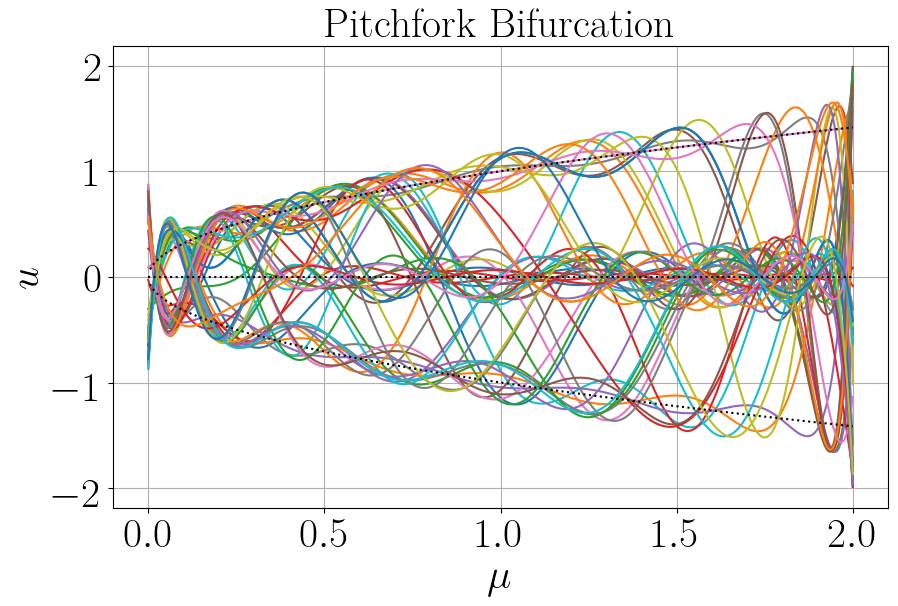

Degree: 10
Accepted polynomials: 52


In [2]:
N_PC_values = [10]
mu = sp.Rational(1, 1)
sigma = sp.Rational(1, 1)
number_of_samples = 100
Bif_values = ["Pitchfork"]

for Bif in Bif_values:
    for N_PC in N_PC_values:
        F, Variables = Build_system(N_PC, Bif)
        G = Build_system_forcing(F, mu, sigma, Variables, Bif)
        solutions = Numerical_system_solver(G, Variables, 100)
        residuals = [0 for _ in range(len(solutions))]
        polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
        Plot_polynomials(polynomials,N_PC,mu,sigma,Bif,save=True)
        number_polynomials = len(polynomials)
        #sampling_peaks = Sampling_histogram(N_PC, float(mu), float(sigma), polynomials, number_of_samples, Bif, graph=True)
        # extrema_peaks = Extrema_histogram(N_PC, float(mu), float(sigma), solutions, polynomials, Bif, graph=True)
                    
        print(f"Degree: {N_PC}")
        print(f"Accepted polynomials: {number_polynomials}")
        #print(f"Peaks of sampling kde: {sampling_peaks}")
        # print(f"Peaks of extrema kde: {extrema_peaks}")


# Plot Polynomials

In [ ]:
N_PC_values = [4,13,14,15]
sigma = sp.Rational(7, 5)
number_of_samples = 100
Bif_values = ["Transcritical","S","Pitchfork"]
mu_values = [[0,sigma,1],[0,sigma],[0,sigma,1]]
Bif_values = ["S"]
mu_values = [[sp.Rational(0,1)]]
sigma = sp.Rational(1, 5)
N_PC_values = [0]

for i, Bif in enumerate(Bif_values):
    for mu in mu_values[i]:
        for N_PC in N_PC_values:

            F, Variables = Build_system(N_PC, Bif)
            G = Build_system_forcing(F, mu, sigma, Variables, Bif)
            solutions = Numerical_system_solver(G, Variables, 1000)
            residuals = [0 for _ in range(len(solutions))]
            polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
            Plot_polynomials(polynomials,N_PC,mu,sigma,Bif,save=False)
            number_polynomials = len(polynomials)
            # sampling_peaks = Sampling_histogram(N_PC, mu, sigma, polynomials, number_of_samples, Bif, graph=True)
            # extrema_peaks = Extrema_histogram(N_PC, mu, sigma, solutions, polynomials, Bif, graph=True)
                        
            print(f"Degree: {N_PC}")
            print(f"Accepted polynomials: {number_polynomials}")
            # print(f"Peaks of sampling kde: {sampling_peaks}")
            # print(f"Peaks of extrema kde: {extrema_peaks}")


# Scatter

In [ ]:
N_PC_values = [10]
mu = sp.Rational(0, 5)
sigma = sp.Rational(1, 5)
number_of_samples = 20
Bif_values = ["Pitchfork"]

for Bif in Bif_values:
    for N_PC in N_PC_values:
        F, Variables = Build_system(N_PC, Bif)
        G = Build_system_forcing(F, mu, sigma, Variables, Bif)
        solutions = Numerical_system_solver(G, Variables, 500)
        residuals = [0 for _ in range(len(solutions))]
        polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
        #Plot_polynomials(polynomials,N_PC,mu,sigma,Bif,save=True)
        number_polynomials = len(polynomials)
        extrema_peaks = Extrema_scatter(N_PC, mu, sigma, solutions, polynomials, Bif, graph=True)
                    
        print(f"Degree: {N_PC}")
        print(f"Accepted polynomials: {number_polynomials}")
        # print(f"Peaks of sampling kde: {sampling_peaks}")
        # print(f"Peaks of extrema kde: {extrema_peaks}")

# Extrema plot

In [ ]:
from matplotlib.colors import PowerNorm


bluemathlab="#065895"
orangemathlab="#f79a25"

N_PC = 8
N_sample_mu = 29

a = sp.Rational(-1,1)       # lower bound of the interval
b = sp.Rational(2,1)        # upper bound of the interval
h = sp.Rational(b - a, N_sample_mu)
Bif = "Pitchfork"

mu = np.arange(a, b + h, h)

N_sample_sigma = 1
sigma = []

for i in range(len(mu)):
    if mu[i]==0:
        sigma.append(sigma[i-1])
    else:
        sigma.append(sp.Rational(abs(mu[i]),50))

mu_values = []
branch_values = []

F, Variables = Build_system(N_PC, Bif)

for i in range(0, N_sample_mu + 1):
            
    H = copy.deepcopy(F)
    G = Build_system_forcing(H, mu[i], sigma[i], Variables, Bif)
        
    solutions = Numerical_system_solver(G, Variables, 100)
    residuals = [0 for i in range(len(solutions))]
    # Generate and validate the set of accepted polynomials

    polynomials = Calculate_polynomials(N_PC, mu[i], sigma[i], solutions, residuals)
    polynomials_symbolic = Calculate_polynomials_symbolic(N_PC, mu[i], sigma[i], solutions, [0 for i in range(len(solutions))])

    x_val, index = find_extrema_num(polynomials_symbolic, mu[i], sigma[i])
    y_val = []


    for l,m in enumerate(index):
        for k in range(0,len(x_val[l])):
            y_val.append(polynomials[m](float(x_val[l][k])))

    x_val = [x_val[l][m] for l in range(len(x_val)) for m in range(len(x_val[l])) ]
    mu_val = [mu[i] for l in range (len(y_val))]
    mu_values.append(mu_val)
    branch_values.append(y_val)

mu_values = [float(item) for sublist in mu_values for item in sublist]
branch_values = [float(item) for sublist in branch_values for item in sublist]

# Construction of the grid
mu_bins = np.linspace(float(a), float(b), 100)
y_bins = np.linspace(min(branch_values), max(branch_values), 200)

H, xedges, yedges = np.histogram2d(mu_values, branch_values, bins=[mu_bins, y_bins])

# Transposition, necessary for imshow
H = H.T

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Show H
im = ax.imshow(H, aspect='auto', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues', norm=PowerNorm(gamma=0.4))
# True Branch
x_vals = np.linspace(float(a), float(b), 400)
if Bif == "Saddle":
    positivi = x_vals[x_vals > 0]
    if len(positivi) > 0:
        ax.plot(positivi, [math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":")
        ax.plot(positivi, [-math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":", label="Solution branches")

if Bif == "Transcritical":  
    ax.plot(x_vals, x_vals, color=orangemathlab, linestyle=':')
    ax.plot(x_vals, np.zeros_like(x_vals), color=orangemathlab, linestyle=':', label="Solution branches")

if Bif == "Pitchfork":
    positivi = x_vals[x_vals > 0]
    if len(positivi) > 0:
        ax.plot(positivi, [math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":")
        ax.plot(positivi, [-math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":", label="Solution branches")
    ax.plot(x_vals, np.zeros_like(x_vals), color=orangemathlab, linestyle=':')

if Bif == "S":
    aux_values = np.linspace(a, b, 100)
    x_values = []
    values = []
    for i in aux_values:
        i = float(i)
        x = sp.Symbol("x")
        f = x**3 - x - i
        sols = sp.Poly(f, x).nroots(maxsteps=200)
        for sol in sols:
            if abs(sp.im(sol)) < 1e-10:
                x_values.append(i)
                values.append(sp.re(sol))
    ax.scatter(x_values, values, color=orangemathlab, marker=".", s=5, label="Solution branches")

ax.set_xlabel('$\mu$')
ax.set_ylabel('Values')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2)
fig.colorbar(im, ax=ax, label='Density')
plt.show()
fig.savefig(f"Plots/{Bif}_Extrema_N_PC={N_PC}_mu_samples={N_sample_mu}.pdf",bbox_inches='tight')

In [ ]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Show H
im = ax.imshow(H, aspect='auto', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='Blues', norm=PowerNorm(gamma=0.4))
# True Branch
x_vals = np.linspace(float(a), float(b), 400)
if Bif == "Saddle":
    positivi = x_vals[x_vals > 0]
    if len(positivi) > 0:
        ax.plot(positivi, [math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":")
        ax.plot(positivi, [-math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":", label="Solution branches")

if Bif == "Transcritical":  
    ax.plot(x_vals, x_vals, color=orangemathlab, linestyle=':')
    ax.plot(x_vals, np.zeros_like(x_vals), color=orangemathlab, linestyle=':', label="Solution branches")

if Bif == "Pitchfork":
    positivi = x_vals[x_vals > 0]
    if len(positivi) > 0:
        ax.plot(positivi, [math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":")
        ax.plot(positivi, [-math.sqrt(p) for p in positivi], color=orangemathlab, linestyle=":", label="Solution branches")
    ax.plot(x_vals, np.zeros_like(x_vals), color=orangemathlab, linestyle=':')

if Bif == "S":
    aux_values = np.linspace(a, b, 100)
    x_values = []
    values = []
    for i in aux_values:
        i = float(i)
        x = sp.Symbol("x")
        f = x**3 - x - i
        sols = sp.Poly(f, x).nroots(maxsteps=200)
        for sol in sols:
            if abs(sp.im(sol)) < 1e-10:
                x_values.append(i)
                values.append(sp.re(sol))
    ax.scatter(x_values, values, color=orangemathlab, marker=".", s=5, label="Solution branches")

ax.set_xlabel('$\mu$')
ax.set_ylabel('Values')
ax.legend(loc='upper left')
fig.colorbar(im, ax=ax, label='Density')
plt.show()
fig.savefig(f"Plots/{Bif}_Extrema_N_PC={N_PC}_mu_samples={N_sample_mu}.pdf",bbox_inches='tight')

In [ ]:
N_PC_max = 4
mu = sp.Rational(1, 1)
sigma = sp.Rational(1, 5)
number_of_samples = 100
Bif = "Saddle"


for N_PC in range(2, N_PC_max + 1):
    F, Variables = Build_system(N_PC, Bif)
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    solutions = Numerical_system_solver(G, Variables, 1000)
    residuals = [0 for _ in range(len(solutions))]
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
    number_polynomials = len(polynomials)
    sampling_peaks = Sampling_histogram(mu, sigma, polynomials, number_of_samples, Bif, graph=True)
    extrema_peaks = Extrema_histogram(N_PC, mu, sigma, solutions, polynomials, Bif, graph=True)
            
    print(f"Degree: {N_PC}")
    print(f"Accepted polynomials: {number_polynomials}")
    print(f"Peaks of sampling kde: {sampling_peaks}")
    print(f"Peaks of extrema kde: {extrema_peaks}")


In [ ]:
import csv
import sympy as sp

N_PC_max = 4
mu = sp.Rational(1, 1)
sigma = sp.Rational(1, 5)
number_of_samples = 100
Bif = "S"

with open(f"Peaks_{N_PC_max}_{float(mu)}_{float(sigma)}_{Bif}.txt", "w") as f:
    for N_PC in range(2, N_PC_max + 1):
        F, Variables = Build_system(N_PC, Bif)
        G = Build_system_forcing(F, mu, sigma, Variables, Bif)
        solutions = Numerical_system_solver(G, Variables, 100)
        residuals = [0 for i in range(len(solutions))]
        polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
        number_polynomials = len(polynomials)
        sampling_peaks = Sampling_histogram(mu, sigma, polynomials, number_of_samples, Bif, graph=False)
        extrema_peaks = Extrema_histogram(N_PC, mu, sigma, solutions, polynomials, Bif, graph=False)

        f.write(f"{N_PC}\n")
        f.write(f"{sampling_peaks}\n")
        f.write(f"{extrema_peaks}\n")
        f.write("-" * 50 + "\n")


In [ ]:
import csv
import sympy as sp

N_PC_max = 20
mu = sp.Rational(1, 1)
sigma = sp.Rational(1, 5)
number_of_samples = 100
Bif = "Saddle"

with open(f"Matrices_{N_PC_max}_{float(mu)}_{float(sigma)}_{Bif}.txt", "w") as f:
    for N_PC in range(2, N_PC_max + 1):
        F, Variables = Build_system(N_PC, Bif)
        G = Build_system_forcing(F, mu, sigma, Variables, Bif)
        solutions = Numerical_system_solver(G, Variables, 1000)
        solution_matrix = np.array(solutions)
        A=solution_matrix.T@solution_matrix
        #print(A)
        eigenvalues, eigenvectors = np.linalg.eig(A)
        sol = np.sort(eigenvalues)
        sol = sol[::-1]
        print(sol/(np.sum(eigenvalues)))

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

N_PC = 7
mu = sp.Rational(1,2)
sigma = sp.Rational(1,1)
Bif = "S"
number_of_samples = 100

F, Variables = Build_system(N_PC, Bif)
print(F)
G = Build_system_forcing(F, mu, sigma, Variables, Bif)
print(G)
solutions = Numerical_system_solver(G, Variables, 1000)
residuals = [0 for i in range(len(solutions))]

# Generate and validate the set of accepted polynomials
polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
number_polynomials = len(polynomials)
print(f"Accepted polynomials: {number_polynomials}")
print("-" * 50)

# Plot the resulting polynomials
Plot_polynomials(polynomials, mu, sigma, Bif)
sampling_peaks = Sampling_histogram(mu, sigma, polynomials, number_of_samples, Bif, graph=True)
extrema_peaks = Extrema_histogram(N_PC, mu, sigma, solutions, polynomials, Bif, graph=True)
            
print(f"Degree: {N_PC}")
print(f"Accepted polynomials: {number_polynomials}")
print(f"Peaks of sampling kde: {sampling_peaks}")
print(f"Peaks of extrema kde: {extrema_peaks}")
print("-"*50)

In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import time
import math
import matplotlib.pyplot as plt

N = 10

for i in range(2,N+1):
    start = time.perf_counter()
    B, F, Variables = Tensor_4_Legendre(i)
    #print(B)
    end = time.perf_counter()
    print(f"NPC = {i}; Tempo impiegato: {end - start:.6f} secondi")
    print(F)




In [ ]:
import sympy as sp

N_PC_max = 7
mu = sp.Rational(1, 1)
sigma = sp.Rational(1, 5)
number_of_samples = 100
Bif = "P"



for N_PC in range(N_PC_max, N_PC_max+1):
    F, Variables = Build_system(N_PC, Bif)
    G = Build_system_forcing(F, mu, sigma, Variables, Bif)
    solutions = Numerical_system_solver(G, Variables, 1000)
    print(solutions)
    residuals = [0 for _ in range(len(solutions))]
    polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
    number_polynomials = len(polynomials)
    Plot_polynomials(polynomials, mu, sigma, Bif)


    polynomials_symbolic = Calculate_polynomials_symbolic(N_PC, mu, sigma, solutions, [0 for i in range(len(solutions))])

    x_val, index = find_extrema_num(polynomials_symbolic, mu, sigma)
    print(x_val)
    
    y_val = []

    for j,i in enumerate(index):
        values = []
        for k in range(0,len(x_val[j])):
            values.append(polynomials[i](float(x_val[j][k])))
        y_val.append(values)
    
    
    peaks = []
    for j in range(0, len(y_val)):
        if len(y_val[j])==N_PC-1:
            sorted = np.sort(y_val[j])
            #peaks.append(sorted)
            peaks.append(y_val[j])
    X = [peaks[i][j] for i in range(len(peaks)) for j in range(N_PC-1)]
    print(f"X: {X}")
    peaks = np.matrix(peaks)
    print(f"Peaks:{peaks}")
    A = peaks.T@peaks
    eigenvalues, eigenvectors = np.linalg.eig(A)
    print(A)
    print(np.sort(eigenvalues/np.sum(eigenvalues))[::-1])

    x_val = [x_val[i][j] for i in range(len(x_val)) for j in range(len(x_val[i])) ]
    y_val = [y_val[i][j] for i in range(len(y_val)) for j in range(len(y_val[i])) ]


    # Determine plot range based on data
    x_max = 2 * max(y_val)
    x_min = -x_max
    # subdivision_number = int(x_max*10)
    subdivision_number = 40
    h = 2*x_max/subdivision_number
    x_range = np.arange(x_min, x_max + float(h), float(h))
    # Create a new plot for histogram and KDE with confidence bands
    

    # Compute Kernel Density Estimate (KDE)
    kde = scp.gaussian_kde(y_val)
    x_kde = np.linspace(x_min, x_max, 1000)
    kde_values = kde(x_kde)

    # Find peaks
    peaks_idx, _ = find_peaks(kde_values)
    
    fig, ax = plt.subplots(1, 1, figsize=(10.5, 5))

    ax.hist(y_val, bins=x_range, density=True, alpha=0.5, label='PDF (Histogram)')

    if Bif == "S":    
        ax.axvline(math.sqrt(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
        ax.axvline(-math.sqrt(mu), color='g', linestyle='dotted', linewidth=2)
    if Bif == "T":    
        ax.axvline(float(mu), color='g', linestyle='dotted', linewidth=2, label="Expected mean value")
        ax.axvline(0, color='g', linestyle='dotted', linewidth=2)

    ax.plot(x_kde, kde_values, color=orangemathlab, label='PDF (KDE)')
        # ax.fill_between(x_kde, lower, upper, color="red", alpha=0.2, label="95% Confidence Interval")

        # Set labels, legend, and grid
    ax.set_xlabel("Values")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True)

        # Display the final plot
    plt.show()



# Prova cubic

In [ ]:
import sympy as sp
from sympy import symbols, integrate

def cubic_projection_legendre(N, simplify=False):
    c = symbols(f"c0:{N}")
    x = sp.Symbol("x")
    P = [sp.legendre(n, x) for n in range(N)]
    u = sum(c[i] * P[i] for i in range(N))
    u_cubed = sp.expand(u**3)
    F = []
    for n in range(N):
        proj = integrate(u_cubed * P[n], (x, -1, 1))
        if simplify:
            proj = sp.simplify(proj)
        F.append(proj)

    return F


import time

MAX = 6
results = {}

for n in range(1, MAX):
    start = time.time()
    F = cubic_projection_legendre(n, simplify=False)
    end = time.time()

    results[f"F{n}"] = F
    print(f"F{n} = {F}")
    print(f"Time for F{n} (N={n}): {end - start:.6f} seconds\n")


In [ ]:
import numpy as np
import sympy as sp
from numpy.polynomial.legendre import leggauss


def _trim_small_terms(expr, tol=1e-12):
    expr = sp.expand(expr)
    if expr.is_Atom:
        return expr
    terms = expr.as_ordered_terms()
    kept_terms = []
    for t in terms:
        c = t.as_coeff_Mul()[0]
        if abs(float(c)) > tol:
            kept_terms.append(t)
    return sum(kept_terms) if kept_terms else sp.Integer(0)


def cubic_projection_legendre_numeric(N, tol=1e-12):
    c = sp.symbols(f"c0:{N}")
    Q = 2 * N
    xs, ws = leggauss(Q)

    P = np.zeros((N, Q))
    x = sp.symbols("x")

    for n in range(N):
        f = sp.lambdify(x, sp.legendre(n, x), "numpy")
        P[n, :] = f(xs)

    u_vals = np.zeros(Q, dtype=object)
    for i in range(N):
        u_vals += c[i] * P[i, :]

    u3_vals = u_vals**3

    F = []
    for n in range(N):
        val = sum(ws[j] * P[n, j] * u3_vals[j] for j in range(Q))
        F.append(_trim_small_terms(val, tol))

    return F


In [ ]:
import time

MAX = 4
results = {}

for n in range(0, MAX+1):
    start = time.time()
    F = cubic_projection_legendre_numeric(n)
    end = time.time()

    results[f"F{n-1}"] = F
    print(f"F{n-1} = {F}")
    print(f"Time for F{n-1} (N={n-1}): {end - start:.6f} seconds\n")
